In [ ]:
import json
import numpy as np
import pandas as pd

# IN_JSON_FILE = "/home/tannier/Recherche/BPI_PARTAGES/cmd/clean_ficticious_reports/out_core_only/patients.json"
# IN_JSON_FILE = "/home/tannier/Recherche/BPI_PARTAGES/cmd/clean_ficticious_reports/out_entire_dataset/patients.json"
# IN_JSON_FILE = "/home/tannier/Recherche/BPI_PARTAGES/cmd/clean_ficticious_reports/final/patients.json"
IN_JSON_FILE = "/home/tannier/Recherche/BPI_PARTAGES/cmd/clean_ficticious_reports/all/patients.json"
# IN_JSON_FILE = "/home/tannier/Téléchargements/patients.json"
OUT_CSV_FILE = "/tmp/patient_stats.csv"

LANG = "FR"

# MEDICAL_SPECIALTIES_FR_EN: dict[str, str] = {
#     "CANCERO ADULTE": "Medical Oncology",
#     "PNEUMOLOGIE": "Pulmonary Medicine",
#     "ANATOMOPATHOLOGIE": "Anatomic Pathology",
#     "CHIRURGIE VISCERALE": "Digestive Surgery",
#     "MALADIES INFECTIEUSES": "Infectious Diseases",
#     "CHIR ORTHO ET TRAUMATO": "Orthopedic Surgery and Traumatology",
#     "NEUROLOGIE": "Neurology",
#     "MEDECINE INTERNE": "Internal Medicine",
#     "GYNECOLOGIE": "Gynecology",
#     "UROLOGIE": "Urology",
#     "OBSTETRIQUE": "Obstetrics",
#     "HEPATO-GASTRO-ENTERO": "Gastroenterology and Hepatology",
#     "MEDECINE GERIATRIQUE": "Geriatric Medicine",
#     "HEMATOLOGIE CLINIQUE": "Hematology",
#     "NEPHROLOGIE": "Nephrology",
#     "MEDECINE INTER-SPECIALITES": "General Internal Medicine",
#     "CARDIOLOGIE": "Cardiology",
#     "MEDECINE PEDIATRIQUE": "Pediatrics",
#     "REANIMATION": "Critical Care Medicine",
#     "CHIR.CARDIO-VASC.": "Cardiovascular Surgery",
# }
MEDICAL_SPECIALTIES_FR_EN: dict[str, str] = {
    "CANCERO ADULTE": "Oncology",
    "PNEUMOLOGIE": "Pulmonology",
    "ANATOMOPATHOLOGIE": "Pathology",
    "CHIRURGIE VISCERALE": "Digestive Surg.",
    "MALADIES INFECTIEUSES": "Infectious Dis.",
    "CHIR ORTHO ET TRAUMATO": "Ortho & Trauma Surg.",
    "NEUROLOGIE": "Neurology",
    "MEDECINE INTERNE": "Internal Med.",
    "GYNECOLOGIE": "Gynecology",
    "UROLOGIE": "Urology",
    "OBSTETRIQUE": "Obstetrics",
    "HEPATO-GASTRO-ENTERO": "Gastro & Hepato",
    "MEDECINE GERIATRIQUE": "Geriatrics",
    "HEMATOLOGIE CLINIQUE": "Hematology",
    "NEPHROLOGIE": "Nephrology",
    "MEDECINE INTER-SPECIALITES": "Gen. Internal Med.",
    "CARDIOLOGIE": "Cardiology",
    "MEDECINE PEDIATRIQUE": "Pediatrics",
    "REANIMATION": "Critical Care",
    "CHIR.CARDIO-VASC.": "Cardiovasc. Surg.",
}

DOCTYPE_FR_EN: dict[str, str] = {
    "ANAPATH": "Pathology",
    "ANAPATH2": "Pathology",
    "CRC": "Consultation",
    "CRO": "Surgical Report",
    "CRH": "Hospital Stay",
    "MATERNITE": "Maternity",
    "NAISSANCE": "Childbirth",
    "URGENCES": "Emergency",
    "ACCOUCHEMENT": "Childbirth",
}

## Construction d'un fichier CSV récapitulatif par document

In [31]:
with open(IN_JSON_FILE, 'r') as f:
    data = json.load(f)
    
tab = []
pools = set()
columns = ['patient_id', 'specialty', 'admission_mode', 'discharge_mode', 'report_type', 'pool', 'word_count']
for patient in data['data']:
    id = patient['id']
    specialty = patient['specialty']
    if LANG == "EN":
        specialty = MEDICAL_SPECIALTIES_FR_EN.get(specialty, specialty)
    admission_mode = patient['suggested_scenario'].get('admission_mode', "")
    discharge_mode = patient['suggested_scenario'].get('discharge_mode', "")
    pool = patient["pool"]
    pools.add(pool)
    for doc in patient["documents"]:
        type = doc['type']
        wc = doc["word_count"]
        tab.append([id, specialty, admission_mode, discharge_mode, type, pool, wc])
df = pd.DataFrame(tab, columns=columns)
df.to_csv(OUT_CSV_FILE, index=False)
print(f"Patient stats written to {OUT_CSV_FILE}")
print(f"Pools: {sorted(list(pools))}")

Patient stats written to /tmp/patient_stats.csv
Pools: ['CU 1 - Pseudonymisation', 'CU 1 - Pseudonymisation_TEST', 'CU 2 - ICD-10 coding', 'CU 2 - ICD-10 coding_TEST', 'CU 5a - Oncology (biomarkers)', 'CU 5a - Oncology (biomarkers)_TEST', 'CU 5b - Oncology (response to treatment)', 'CU 5b - Oncology (response to treatment)_TEST', 'CU 6 - Infectiology', 'CU 6 - Infectiology_TEST', 'General']


In [42]:
with open(IN_JSON_FILE, 'r') as f:
    data = json.load(f)
    
tab = []
all_cat = set()
patients_counts = {}
doc_counts = {}
n = 0

for patient in data['data']:
    id = patient['id']    
    pool = patient["pool"]    

    if "_TEST" in pool:
        pool, split = pool.split("_")[0], "Embargoed (held-out)"
    else:
        pool, split = pool, "Released"
    patients_counts[pool + "_" + split] = patients_counts.get(pool + "_" + split, 0) + 1
    doc_counts[pool + "_" + split] = doc_counts.get(pool + "_" + split, 0) + len(patient["documents"])
    
data = []
for pool_split, count in patients_counts.items():
    pool, split = pool_split.split("_")
    data.append([pool, split, count, doc_counts[pool_split]])
df = pd.DataFrame(data, columns=["Pool", "Split", "Patient Count", "Document Count"])
df.sort_values(by=["Pool", "Split"], inplace=True)
df

,Pool,Split,Patient Count,Document Count
6,CU 1 - Pseudonymisation,Embargoed (held-out),337,395
5,CU 1 - Pseudonymisation,Released,509,619
7,CU 2 - ICD-10 coding,Embargoed (held-out),198,594
8,CU 2 - ICD-10 coding,Released,288,864
2,CU 5a - Oncology (biomarkers),Embargoed (held-out),53,53
1,CU 5a - Oncology (biomarkers),Released,147,150
4,CU 5b - Oncology (response to treatment),Embargoed (held-out),101,101
3,CU 5b - Oncology (response to treatment),Released,108,108
9,CU 6 - Infectiology,Embargoed (held-out),66,66
10,CU 6 - Infectiology,Released,134,134


### Comptes par spécialité (par patient et par document)

In [ ]:
with open(IN_JSON_FILE, 'r') as f:
    data = json.load(f)
    
tab = []
all_cat = set()
counts = {}

for patient in data['data']:
    id = patient['id']
    specialty = patient["specialty"]
    if LANG == "EN":
        specialty = MEDICAL_SPECIALTIES_FR_EN.get(specialty, specialty)
    previous = counts.get(specialty, [0, 0])
    counts[specialty] = [previous[0] + 1, previous[1] + len(patient["documents"])]
    # all_cat.add(patient['suggested_scenario'].get('discharge_mode', None))
    # for doc in patient["documents"]:
    #     try:
    #         cat = doc['type']
    #     except KeyError:
    #         continue
    # all_cat.add(cat)
    # admission_mode = patient['suggested_scenario']['admission_mode']
    # discharge_mode = patient['suggested_scenario']['discharge_mode']
    # pool = patient["pool"]
    # for doc in patient["documents"]:
    #     type = doc['type']
    #     wc = doc["word_count"]
    #     tab.append([id, specialty, admission_mode, discharge_mode, type, pool, wc])
df = pd.DataFrame.from_dict(counts, orient='index', columns=['patient_count', 'document_count']).reset_index().rename(columns={'index': 'specialty'}).sort_values(by='patient_count', ascending=False)
df
# df.to_csv(OUT_CSV_FILE, index=False)
# print(f"Patient stats written to {OUT_CSV_FILE}")

,specialty,patient_count,document_count
1,CANCERO ADULTE,608,608
17,PNEUMOLOGIE,587,587
0,ANATOMOPATHOLOGIE,485,491
5,CHIRURGIE VISCERALE,381,1107
9,MALADIES INFECTIEUSES,351,351
3,CHIR ORTHO ET TRAUMATO,308,881
15,NEUROLOGIE,290,290
12,MEDECINE INTERNE,270,270
6,GYNECOLOGIE,235,651
19,UROLOGIE,218,632


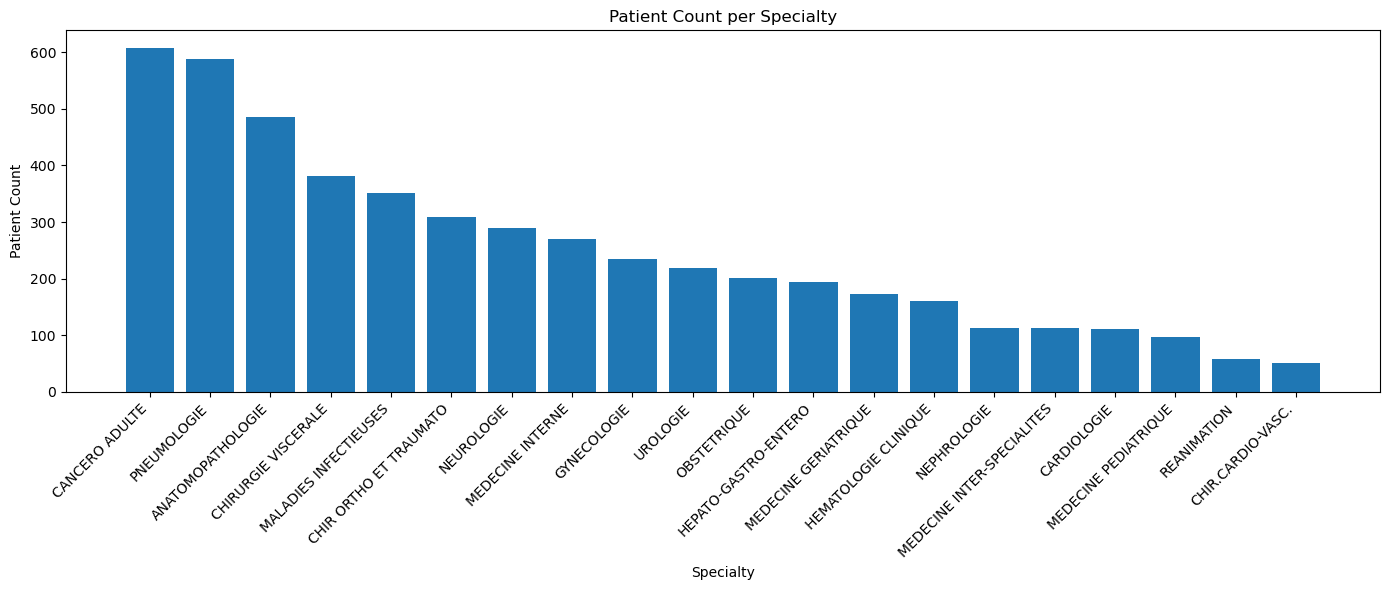

In [33]:
# Create a bar plot of patient_count per specialty
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))
plt.bar(df['specialty'], df['patient_count'])
plt.xlabel('Specialty')
plt.ylabel('Patient Count')
plt.title('Patient Count per Specialty')
plt.xticks(rotation=45, ha='right')
# Shift the x labels to the left so that the end of the last label is at the end of the plot

plt.subplots_adjust(bottom=0.2)
plt.tight_layout()
plt.show()

### Comptes par spécialité (par patient et par document) en séparant core et use cases

In [34]:
with open(IN_JSON_FILE, 'r') as f:
    data = json.load(f)
    
tab = []
all_cat = set()
counts = {}
all_pools = ("General Pool", "Use case ICD-10 coding", "Use case Oncology (biomarkers)", "Use case Oncology (response to treatment)", "Use case Infectiology")
n = 0
for patient in data['data']:
    id = patient['id']
    specialty = patient["specialty"]
    if LANG == "EN":
        specialty = MEDICAL_SPECIALTIES_FR_EN.get(specialty, specialty)
    pool = patient["pool"]

    if "_TEST" in pool:
        pool, split = pool.split("_")[0], "Embargoed (held-out)"
    else:
        pool, split = pool, "Released"
        
    if pool == "CU 1" or pool == "CU 1 - Pseudonymisation":
        pool = "General Pool"
    elif pool == "CU 2" or pool == "CU 2 - ICD-10 coding":
        pool = "Use case ICD-10 coding"
    elif pool == "CU 5a" or pool == "CU 5a - Oncology (biomarkers)":
        pool = "Use case Oncology (biomarkers)"
    elif pool == "CU 5b" or pool == "CU 5b - Oncology (response to treatment)":
        pool = "Use case Oncology (response to treatment)"
    elif pool == "CU 6" or pool == "CU 6 - Infectiology":
        pool = "Use case Infectiology"
    elif pool.lower() == "general":
        pool = "General Pool"
    else:
        raise ValueError(f"Unexpected pool: {pool}")
        
    assert split in ["Embargoed (held-out)", "Released"], f"Unexpected split: {split}"
    
    if pool == "General Pool":
        n += len(patient["documents"])
    
    tab.append([specialty, pool, split])
    # # Data structure for each specialty: 
    # # [general pool patient count, general pool document count, 
    # #  cu5a_patient_count, cu5a_document_count, 
    # #  cu5b_patient_count, cu5b_document_count,
    # #  cu6_patient_count, cu6_document_count]
    # previous = counts.get(specialty, [0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    
    # if pool == "CU 6":
    #     previous[8] += 1
    #     previous[9] += len(patient["documents"])
    # elif pool == "CU 5a":   
    #     previous[4] += 1
    #     previous[5] += len(patient["documents"])
    # elif pool == "CU 5b":
    #     previous[6] += 1
    #     previous[7] += len(patient["documents"])
    # elif pool == "CU 2":
    #     previous[2] += 1
    #     previous[3] += len(patient["documents"])
    # else:
    #     previous[0] += 1
    #     previous[1] += len(patient["documents"])
    
    # counts[specialty] = previous
    # # all_cat.add(patient['suggested_scenario'].get('discharge_mode', None))
    # # for doc in patient["documents"]:
    # #     try:
    # #         cat = doc['type']
    # #     except KeyError:
    # #         continue
    # # all_cat.add(cat)
    # # admission_mode = patient['suggested_scenario']['admission_mode']
    # # discharge_mode = patient['suggested_scenario']['discharge_mode']
    # # pool = patient["pool"]
    # # for doc in patient["documents"]:
    # #     type = doc['type']
    # #     wc = doc["word_count"]
    # #     tab.append([id, specialty, admission_mode, discharge_mode, type, pool, wc])
    
df = pd.DataFrame(tab, columns=['specialty', 'pool', 'split'])
df


,specialty,pool,split
0,ANATOMOPATHOLOGIE,General Pool,Released
1,ANATOMOPATHOLOGIE,General Pool,Released
2,ANATOMOPATHOLOGIE,General Pool,Released
3,ANATOMOPATHOLOGIE,General Pool,Released
4,ANATOMOPATHOLOGIE,General Pool,Released
...,...,...,...
5004,UROLOGIE,Use case ICD-10 coding,Embargoed (held-out)
5005,UROLOGIE,Use case ICD-10 coding,Embargoed (held-out)
5006,UROLOGIE,Use case ICD-10 coding,Released
5007,UROLOGIE,Use case ICD-10 coding,Released


In [29]:
counts = (
    df.groupby(["specialty", "pool", "split"])
      .size()
      .unstack(["pool", "split"], fill_value=0)
)
pool_counts = counts["General Pool"]
totals = pool_counts.sum(axis=1)
counts = counts.loc[totals.sort_values(ascending=False).index]

assert counts.sum().sum() == len(data['data']), f"Total patient count mismatch: {counts.sum().sum()} vs {len(data['data'])}"
counts

pool,General Pool,Use case Oncology (biomarkers),Use case Oncology (response to treatment),Use case ICD-10 coding,Use case Infectiology
split,Released,Released,Released,Released,Released
specialty,,,,,
PNEUMOLOGIE,531,0,0,0,0
CANCERO ADULTE,399,0,108,0,0
ANATOMOPATHOLOGIE,285,147,0,0,0
NEUROLOGIE,251,0,0,0,0
MEDECINE INTERNE,228,0,0,0,0
GYNECOLOGIE,212,0,0,0,0
OBSTETRIQUE,174,0,0,0,0
CHIRURGIE VISCERALE,170,0,0,125,0


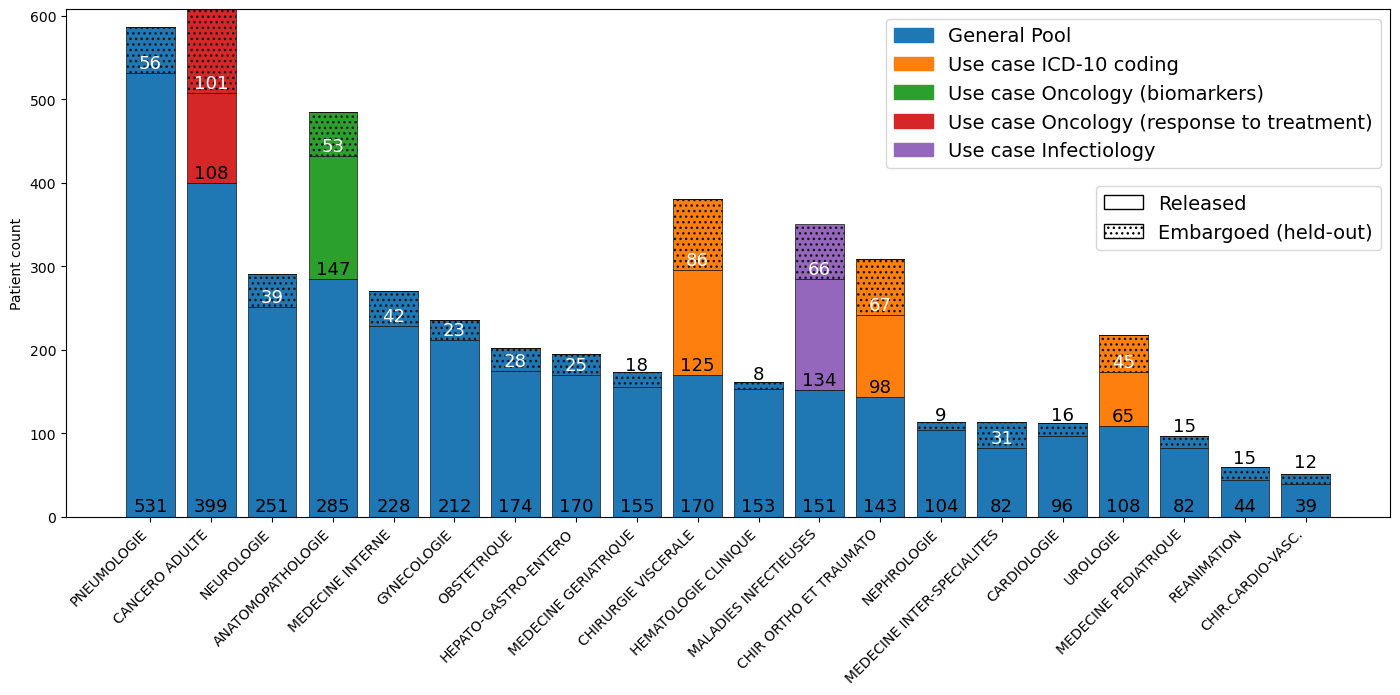

In [10]:
def plot_stacked_bar(
    counts: pd.DataFrame,
) -> None:
    """
    Plot stacked bar chart with:
    - x-axis = specialty
    - color = pool
    - hatch = split

    Parameters
    ----------
    counts : pd.DataFrame
        Output of compute_counts().
    """
    specialties = counts.index.tolist()
    splits = ("Released", "Embargoed (held-out)")
    assert all(pool in counts.columns.levels[0] for pool in all_pools), f"Expected pools {all_pools} not all found in counts columns {counts.columns.levels[0]}"
    assert all(split in counts.columns.levels[1] for split in splits), f"Expected splits {splits} not all found in counts columns {counts.columns.levels[1]}"

    x = np.arange(len(specialties))
    bottom = np.zeros(len(specialties))

    fig, ax = plt.subplots(figsize=(14, 7))
    # Set font size 
    plt.rcParams.update({'font.size': 14})

    # Define colors and hatches
    color_map = plt.cm.tab10.colors
    pool_colors = {
        pool: color_map[i % len(color_map)]
        for i, pool in enumerate(all_pools)
    }

    hatch_patterns = {
        split: hatch
        for split, hatch in zip(splits, ["", "...", "\\\\", "//", "xx", "oo"])
    }

    for pool in all_pools:
        for split in splits:
            if (pool, split) not in counts.columns:
                continue

            values = counts[(pool, split)].values

            bars = ax.bar(
                x,
                values,
                bottom=bottom,
                color=pool_colors[pool],
                hatch=hatch_patterns[split],
                edgecolor="#131313",
                linewidth=0.5,
            )
            
            # ---- Add labels ----
            # for i, value in enumerate([value1, other_values]):
            for i, value in enumerate(values):
                if value == 0:
                    continue

                if split != "Released":
                    color = "#FFFFFF"
                else:
                    color = "#000000"

                if value < 10:
                    additional_offset = 18
                    color = "#000000"
                elif value < 20:
                    additional_offset = 26
                    color = "#000000"
                else:
                    additional_offset = 12

                ax.text(
                    x[i],
                    bottom[i] + additional_offset, # + value, # / 2,
                    str(int(value)),
                    ha="center",
                    va="center",
                    fontsize=13,
                    color=color,
                )            

            bottom += values

    ax.set_xticks(x)
    ax.set_xticklabels(specialties, rotation=45, ha="right")
    ax.set_ylabel("Patient count")
    # ax.set_title("Stacked distribution by specialty")

    # Legend 1: pool (color)
    pool_handles = [
        plt.Rectangle((0, 0), 1, 1, color=pool_colors[pool])
        for pool in all_pools
    ]
    pool_legend = ax.legend(
        pool_handles,
        all_pools,
        # title="Pool",
        loc="upper right",
    )
    ax.add_artist(pool_legend)

    # Legend 2: split (hatch)
    split_handles = [
        plt.Rectangle(
            (0, 0),
            1,
            1,
            facecolor="white",
            edgecolor="black",
            hatch=hatch_patterns[split],
        )
        for split in splits
    ]
    ax.legend(
        split_handles,
        splits,
        # title="Split",
        loc="upper right",
        bbox_to_anchor=(1.0, 0.67),  # ↓ slightly lower        
    )

    plt.tight_layout()
    fig.subplots_adjust(
        left=0.052,
        right=0.998,
        # top=0.95,
        bottom=0.245,
    )

    plt.savefig("/tmp/patient_count_per_specialty_and_pool.png", dpi=300, transparent=True)
    plt.show()
    
plot_stacked_bar(counts)

### Nombre de mots

In [11]:
with open(IN_JSON_FILE, 'r') as f:
    data = json.load(f)
    
tab = []
all_cat = set()
counts = {}

df_data = []
for patient in data['data']:
    id = patient['id']
    for doc in patient["documents"]:
        doc_type = doc['type']
        if doc_type == "ANAPATH2":
            doc_type = "ANAPATH"
        if LANG == "EN":
            doc_type = DOCTYPE_FR_EN.get(doc_type, doc_type)
        word_count = doc["word_count"]
        df_data.append([id, doc_type, word_count])
df = pd.DataFrame(df_data, columns=['patient_id', 'document_type', 'word_count'])
df
    

,patient_id,document_type,word_count
0,ANATOMOPATHOLOGIE-00001,ANAPATH,347
1,ANATOMOPATHOLOGIE-00002,ANAPATH,320
2,ANATOMOPATHOLOGIE-00003,ANAPATH,508
3,ANATOMOPATHOLOGIE-00004,ANAPATH,739
4,ANATOMOPATHOLOGIE-00005,ANAPATH,717
...,...,...,...
7389,UROLOGIE-00308,CRO,332
7390,UROLOGIE-00308,CRH,80
7391,UROLOGIE-00309,CRC,253
7392,UROLOGIE-00309,CRO,270


In [12]:
# Get min, max, mean, median, std of word_count per document_type
stats = df['word_count'].agg(['min', 'max', 'mean', 'median', 'std', 'count']).reset_index()
stats

,index,word_count
0,min,24.000000
1,max,5370.000000
2,mean,619.770084
3,median,491.000000
4,std,499.885922
5,count,7394.000000


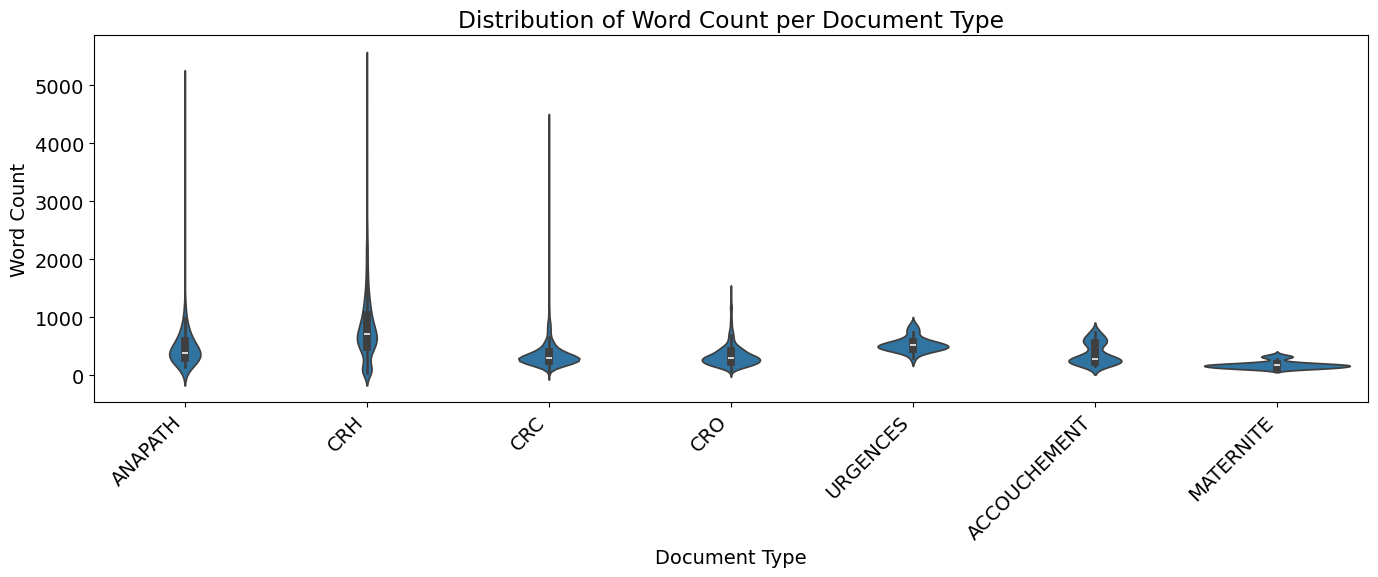

In [13]:
# Create a violin plot of word_count per document_type
plt.figure(figsize=(14, 6))
# Set font size
plt.rcParams.update({'font.size': 14})
import seaborn as sns
sns.violinplot(x='document_type', y='word_count', data=df)
plt.xlabel('Document Type')
plt.ylabel('Word Count')
plt.title('Distribution of Word Count per Document Type')
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.2)
plt.tight_layout()
plt.show()

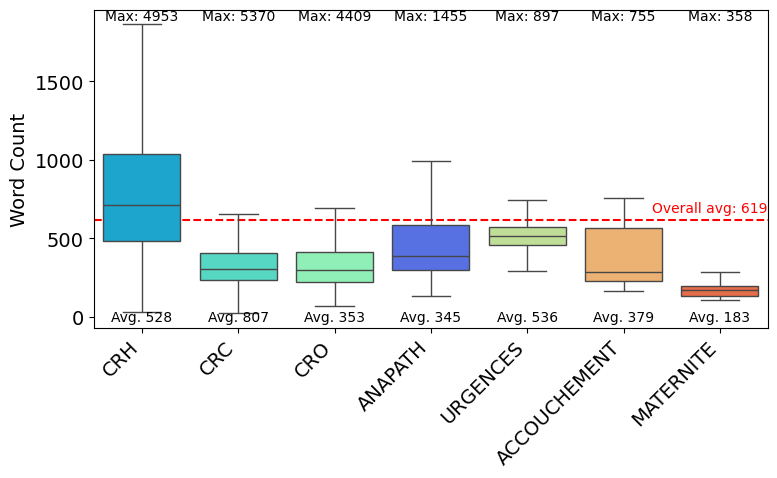

In [14]:
# Create a stripplot of word counts per document type
import seaborn as sns
plt.figure(figsize=(8, 5))

# Get the average word count overall
overall_mean = df['word_count'].mean()
# Add a horizontal line for the overall average word count
plt.axhline(overall_mean, color='red', linestyle='--', label=f'Overall Average: {int(overall_mean)}')
# Add a text label for the overall average line
plt.text(len(df['document_type'].unique()) - 0.5, overall_mean + 30, f'Overall avg: {int(overall_mean)}', color='red', ha='right', va='bottom', fontsize=10)
# boxplot with one dot per document, jittered on the x axis, and colored by document type
# rainbow palette with as many colors as document types, ordered by the number of documents of each type
palette = sns.color_palette("rainbow", n_colors=df['document_type'].nunique())
# Order
order=df['document_type'].value_counts().index
# do not show x legend
sns.boxplot(y='word_count', x="document_type", hue="document_type", order=order,data=df, showfliers=False, palette=palette, legend=False)
# sns.stripplot(y='word_count', x="document_type", data=df, jitter=True, alpha=1, size=1, hue_order=df['document_type'].value_counts(ascending=False).index)
# Add mean and max values on top of each box
for i, doc_type in enumerate(df['document_type'].unique()):
    mean = df[df['document_type'] == doc_type]['word_count'].mean()
    max_value = df[df['document_type'] == doc_type]['word_count'].max()
    plt.text(i, -50, f'Avg. {int(mean)}', ha='center', va='bottom', fontsize=10)
    plt.text(i, 1870, f'Max: {int(max_value)}', ha='center', va='bottom', fontsize=10)
plt.xlabel('')
plt.ylabel('Word Count')
# plt.title('Word Count per Document Type')
# Remove xtick labels 
# plt.xticks([])
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.2)
plt.tight_layout()

# Save the plot to a high resolution PNG file
plt.savefig('/tmp/word_count_per_document_type.png', dpi=300, transparent=True)
plt.show()

### Nombre de documents de chaque type

Avec le nombre de documents par patients

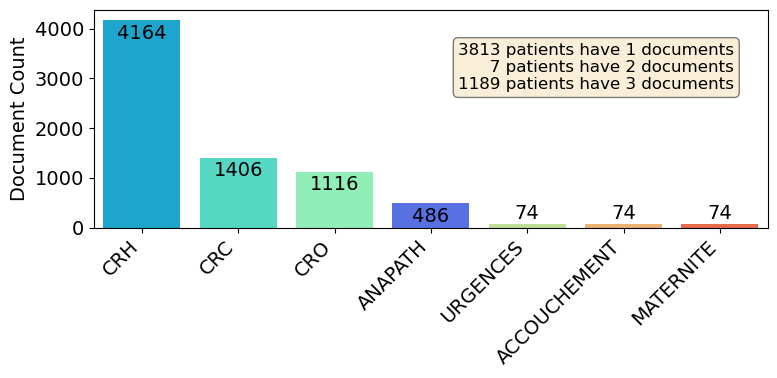

In [15]:
with open(IN_JSON_FILE, 'r') as f:
    data = json.load(f)
    
tab = []
all_cat = set()
counts = {}

df_data = []
for patient in data['data']:
    id = patient['id']
    for doc in patient["documents"]:
        doc_type = doc['type']
        if doc_type == "ANAPATH2":
            doc_type = "ANAPATH"
        if LANG == "EN":
            doc_type = DOCTYPE_FR_EN.get(doc_type, doc_type)
        df_data.append([id, doc_type, len(patient["documents"])])
df = pd.DataFrame(df_data, columns=['patient_id', 'document_type', 'document_count'])

# Number of documents per patient_id
doc_counts = df.groupby('patient_id')['document_type'].count().reset_index().rename(columns={'document_type': 'document_count'})
doc_counts_agg = doc_counts.groupby('document_count')['patient_id'].count().reset_index()
distribution_str = '\n'.join([f'{row.patient_id:>4} patients have {row.document_count} documents' for _, row in doc_counts_agg.iterrows()])

# Create a boxplot of document counts per document type
plt.figure(figsize=(8, 4))
# Set font size
plt.rcParams.update({'font.size': 14})
palette = sns.color_palette("rainbow", n_colors=df['document_type'].nunique())
sns.countplot(x='document_type', data=df, order=df['document_type'].value_counts().index, 
              hue="document_type", palette=palette, legend=False)
# Add values on top of each bar
for i, doc_type in enumerate(df['document_type'].value_counts().index):
    count = df[df['document_type'] == doc_type].shape[0]
    if count > 200:
        plt.text(i, count - 450, str(count), ha='center', va='bottom', fontsize=14)
    else:
        plt.text(i, count + 10, str(count), ha='center', va='bottom', fontsize=14)
# Add a text box with the number of documents per patient
# place a text box in upper left in axes coords
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(0.95, 0.85, distribution_str, transform=plt.gca().transAxes, fontsize=12,
         horizontalalignment='right',
        verticalalignment='top', bbox=props)

plt.xlabel('')
plt.ylabel('Document Count')
# plt.title('Document Count per Document Type')
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.2)
plt.tight_layout()
# Save the plot to a high resolution PNG file
plt.savefig('/tmp/document_count_per_document_type.png', dpi=300, transparent=True)
plt.show()

In [13]:
doc_counts
# Aggregate by document count and get the number of patients for each document count
doc_counts_agg = doc_counts.groupby('document_count')['patient_id'].count().reset_index()
# Build string representation of the distribution of document counts per patient
distribution_str = ', '.join([f'{row.document_count} documents: {row.patient_id} patients' for _, row in doc_counts_agg.iterrows()])
print(f'Distribution of document counts per patient: {distribution_str}')

Distribution of document counts per patient: 1 documents: 3813 patients, 2 documents: 7 patients, 3 documents: 1189 patients


### Nombre de documents par patient

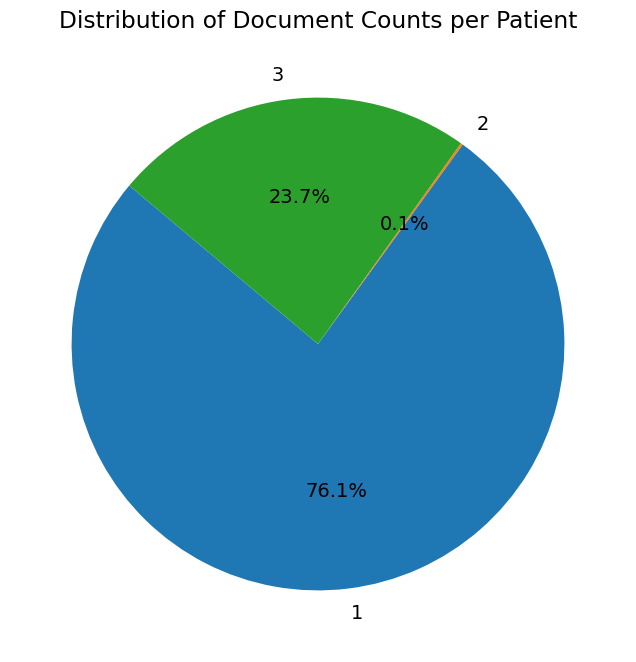

In [14]:
with open(IN_JSON_FILE, 'r') as f:
    data = json.load(f)
    
tab = []
all_cat = set()
counts = {}

df_data = []
for patient in data['data']:
    id = patient['id']
    df_data.append([id, len(patient["documents"])])
df = pd.DataFrame(df_data, columns=['patient_id', 'document_count'])

# Get document count distribution
doc_count_dist = df['document_count'].value_counts().sort_index()

# Create a pie chart of document count distribution
plt.figure(figsize=(8, 8))
# Set font size
plt.rcParams.update({'font.size': 14})
plt.pie(doc_count_dist, labels=doc_count_dist.index, autopct='%1.1f%%', startangle=140) # type: ignore
plt.title('Distribution of Document Counts per Patient')
# Save the plot to a high resolution PNG file
plt.savefig('/tmp/document_count_distribution.png', dpi=300)
plt.show()

### Nombre de patients rédigés par auteur

In [15]:
with open(IN_JSON_FILE, 'r') as f:
    data = json.load(f)
    
tab = []
all_cat = set()
counts = {}


for patient in data['data']:
    id = patient['id']
    specialty = patient["author"]
    previous = counts.get(specialty, [0, 0])
    counts[specialty] = [previous[0] + 1, previous[1] + len(patient["documents"])]
df = pd.DataFrame.from_dict(counts, orient='index', columns=['patient_count', 'document_count']).reset_index().rename(columns={'index': 'author'}).sort_values(by='patient_count', ascending=False)
df

    

,author,patient_count,document_count
22,BDU,186,537
56,ABA,156,156
35,NLE,139,337
41,NHI,130,130
2,EGU,129,129
...,...,...,...
43,ERO,2,2
40,TRO,2,2
67,RDE,2,2
71,AMO,1,1


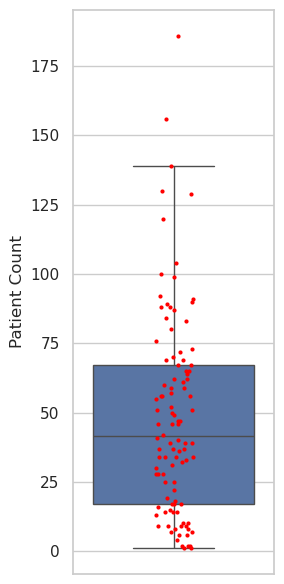

In [16]:
# Use seaborn boxplot and stripplot to create a boxplot of patient counts by author
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")
plt.figure(figsize=(3, 6))
sns.boxplot(y='patient_count', data=df, showfliers=False)
sns.stripplot(y='patient_count', data=df, color='red', jitter=True, size=3)
plt.xticks(rotation=45)
# plt.title('Patient Counts by Author')
# plt.xlabel('Author')
plt.ylabel('Patient Count')
plt.tight_layout()
# Save with high resolution
plt.savefig('/tmp/patient_counts_by_author.png', dpi=300, transparent=True)
plt.show()

### Pyramides des âges

In [17]:
### Pyramide des âges
with open(IN_JSON_FILE, 'r') as f:
    data = json.load(f)
    tab = []
    for patient in data['data']:
        age = patient['suggested_scenario']['age']
        age_value = age["value"]
        age_unit = age["unit"]
        if age_unit == "ans":
            age_in_years = age_value
        elif age_unit == "mois":
            age_in_years = int(age_value / 12)
        else:
            raise ValueError(f"Unexpected age unit: {age_unit}")
            
        sex = patient["suggested_scenario"]["sex"]
        tab.append((age_in_years, sex)) 

df = pd.DataFrame(tab, columns=['age_in_years', 'sex'])
df

,age_in_years,sex
0,76,F
1,59,F
2,69,F
3,56,F
4,74,F
...,...,...
5004,65,F
5005,53,M
5006,55,M
5007,54,M


In [18]:

# Define bins
start, end, step = 0, 91, 4
bins = np.arange(start, end, step)
labels = [f"{i}-{i+step}" for i in bins[:-1]]

df["age_group"] = pd.cut(
    df["age_in_years"],
    bins=bins,
    labels=labels,
    right=False
)
counts = (
    df.groupby(["age_group", "sex"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)
for col in ["M", "F"]:
    if col not in counts:
        counts[col] = 0
counts


/tmp/ipykernel_567774/2320137626.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["age_group", "sex"])


sex,F,M
age_group,,
0-4,22,34
4-8,13,24
8-12,11,25
12-16,21,26
16-20,38,21
20-24,77,31
24-28,58,43
28-32,89,43
32-36,121,35


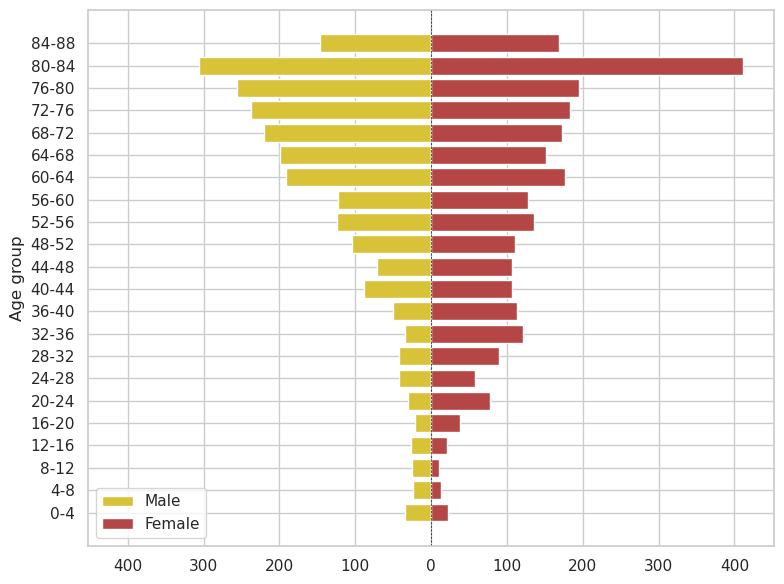

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    counts.index,
    -counts["M"], color="#d7c238", 
    label="Male"
)

ax.barh(
    counts.index,
    counts["F"], color="#b44646",
    label="Female"
)

# Vertical center line
ax.axvline(0, color="#131313", linestyle="--", linewidth=0.5)

# Labels
# ax.set_xlabel("Count")
ax.set_ylabel("Age group")

# Make x-axis symmetric
max_value = max(counts["M"].max(), counts["F"].max())
ax.set_xlim(-max_value * 1.1, max_value * 1.1)

max_tick = (max_value // 100) * 100
plt.xticks(range(-max_tick,max_tick+1, 100), ["{}".format(abs(i)) for i in range(-max_tick,max_tick+1, 100)]);

ax.legend()

plt.tight_layout()
plt.savefig('/tmp/age_pyramid.png', dpi=300, transparent=True)
plt.show()        

### Compter les diagnostics primaires

Number of patients with primary diagnosis: 3068


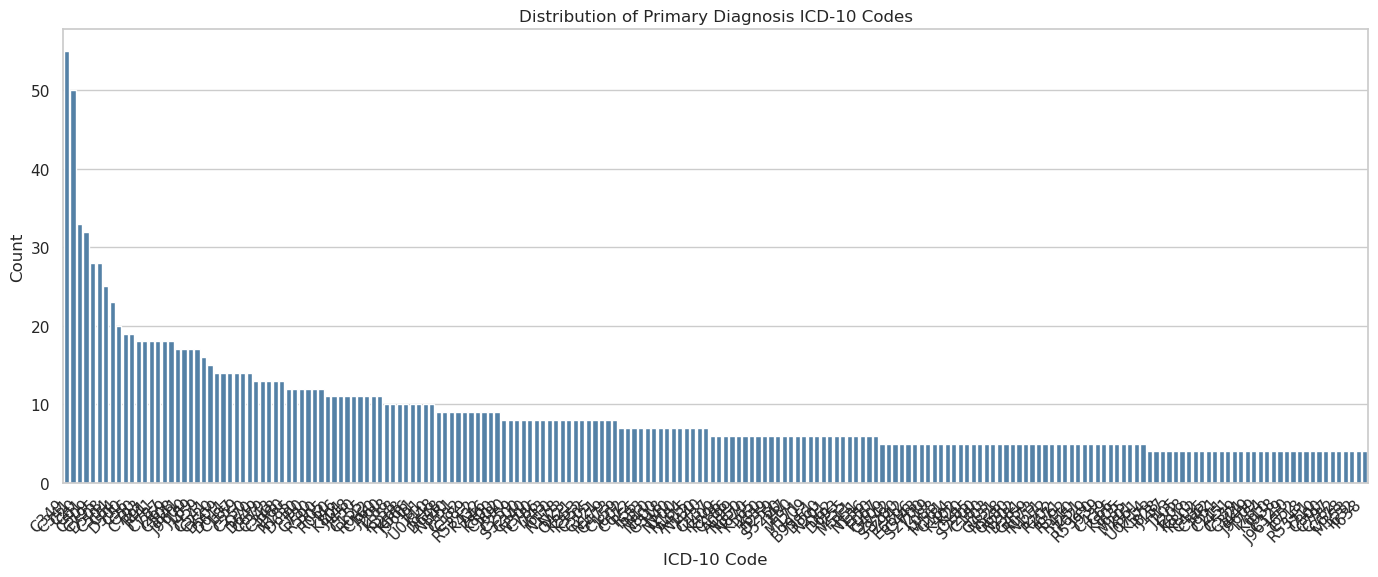

In [20]:
### Compter les diagnostics primaires
with open(IN_JSON_FILE, 'r') as f:
    data = json.load(f)
    tab = []
    out = 0
    for patient in data['data']:
        pool = patient["pool"]
        if pool != "general":
            continue
        icd_10_code = patient['suggested_scenario']['primary_diagnosis'][0]["code"]
        # keep only the first 3 characters of the ICD-10 code
        # icd_10_code = icd_10_code[:3]
        tab.append(icd_10_code) 

df = pd.DataFrame(tab, columns=['icd_10_code'])

print(f"Number of patients with primary diagnosis: {len(df)}")

# Sort and build a bar plot 
icd_10_counts = df['icd_10_code'].value_counts().sort_index()
# Sort
icd_10_counts = icd_10_counts.sort_values(ascending=False)[:200]
plt.figure(figsize=(14, 6))
# Set font size
plt.rcParams.update({'font.size': 14})
sns.barplot(x=icd_10_counts.index, y=icd_10_counts.values, color="#4682b4")
plt.xlabel('ICD-10 Code')
plt.ylabel('Count')
plt.title('Distribution of Primary Diagnosis ICD-10 Codes')
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.2)
plt.tight_layout()
plt.savefig('/tmp/primary_diagnosis_icd10_distribution.png', dpi=300, transparent=True)
plt.show()